In [1]:
# Setup

import os
from prophet import Prophet

env_path = r"C:\Users\Kura\anaconda3\envs\prophet"
extra_paths = [
    env_path,
    os.path.join(env_path, "Library", "mingw-w64", "bin"),
    os.path.join(env_path, "Library", "usr", "bin"),
    os.path.join(env_path, "Library", "bin"),
    os.path.join(env_path, "Scripts"),
]
os.environ["PATH"] = os.pathsep.join(extra_paths) + os.pathsep + os.environ["PATH"]

In [ ]:
import pandas as pd

df = pd.read_csv("airline-passengers.csv")
df['Month'] = pd.to_datetime(df['Month'], format="%Y-%m")
df = df.set_index('Month')

print(df.head())
print(df.info())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


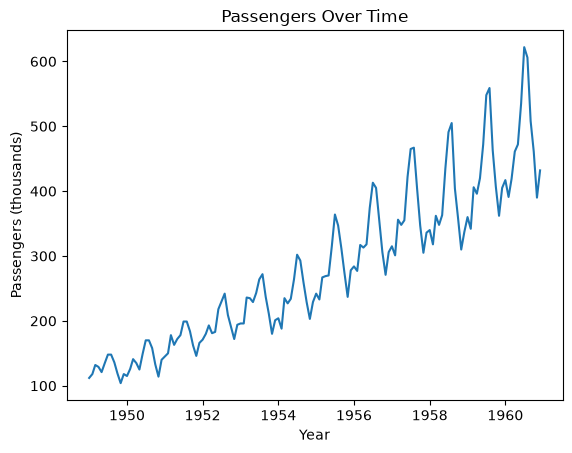

In [ ]:
# Plot the Raw Data

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(df.index, df.values)

plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.title('Passengers Over Time')

plt.show()

# Trending upward with an uptick of passengers for every year

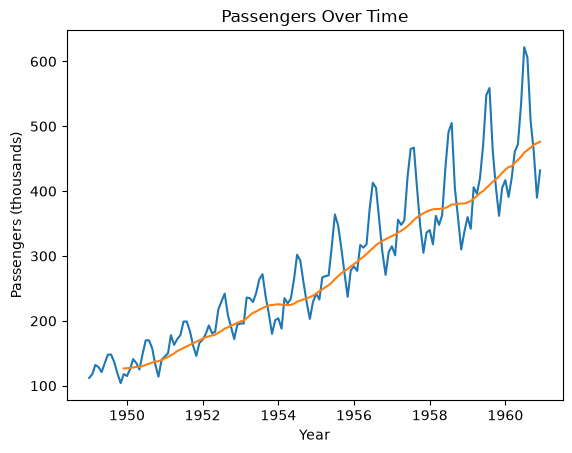

In [ ]:
# Find the Trend by Eye

# The trend is going up

df['RollingMean'] = df['Passengers'].rolling(window=12).mean()

fig, ax = plt.subplots()

plt.plot(df.index, df['Passengers'])
plt.plot(df.index, df['RollingMean'])

plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.title('Passengers Over Time')

plt.show()

# Makes the trend easier to see

C:\Users\Kura\AppData\Local\Temp\ipykernel_31404\3616371223.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(months)


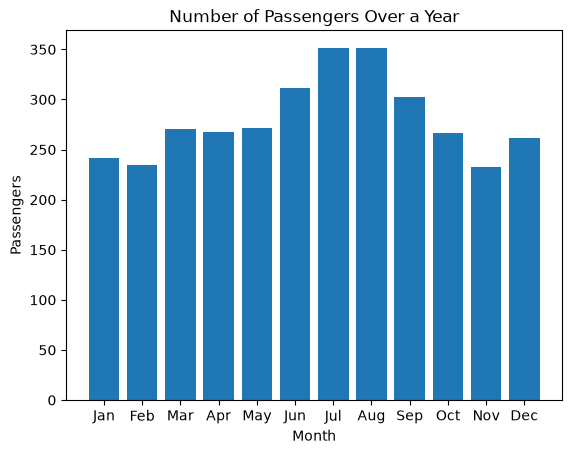

In [43]:
# Find the Seasonality by Line

month_avg = df.groupby(df.index.month)['Passengers'].mean()

months = df.index.strftime('%b')


fig, ax = plt.subplots()

ax.bar(month_avg.index, month_avg.values)
ax.set_xlabel('Month')
ax.set_ylabel('Passengers')
ax.set_xticklabels(months)
ax.set_xticks(month_avg.index)
ax.set_title('Number of Passengers Over a Year')

plt.show()

In [47]:
# Reformat the Data for Prophet

df_prophet = pd.read_csv('airline-passengers.csv')

df_prophet = df.rename(columns={"Month": "ds", "Passengers": "y"})

print(df_prophet.head())

        ds    y
0  1949-01  112
1  1949-02  118
2  1949-03  132
3  1949-04  129
4  1949-05  121
